# 5. Hits and effects

This page asks which treatments moved away from the controls, and which measurements changed.
Both answers come with a p-value from a permutation null, and both are computed on the same
object.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import mantispy as mt

## A plate with known answers

`synthetic_plate` injects a known effect into known features, so every result on this page
can be checked against `uns["mantispy"]["truth"]`.

In [2]:
cells = mt.ds.synthetic_plate(n_wells=192, n_cells=40, n_features=25, n_perturbations=3, effect_size=3.0, seed=0)
mt.pp.normalize(cells, by="Metadata_Plate", reference="negcon")
wells = mt.tl.aggregate(cells, min_cells=0)
wells

AnnData object with n_obs × n_vars = 192 × 25
    obs: 'Metadata_Plate', 'Metadata_Well', 'Metadata_CellCount', 'Metadata_Row', 'Metadata_Col', 'Metadata_Perturbation', 'Metadata_Control', 'Metadata_Batch', 'Metadata_ImageNumber'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature', 'degenerate_scale'
    uns: 'mantispy'
    layers: None (.X)

## Calling hits

`tl.hit_calling` measures how far each group sits from the controls and compares that with a
null built by drawing groups of the same size from the control wells. The question is
whether this group is further out than the same number of control wells would be.

Drawing the null from all rows would put the real hits into the null, and a screen where half
the compounds work would look like one where none do.

A permutation p-value is never zero. With 1000 permutations the smallest possible value is
1/1001, and anything smaller would claim more resolution than the permutations provide.

In [3]:
mt.tl.hit_calling(wells, n_permutations=1000)
wells.uns["mantispy"]["hits"].round(4)

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_98899/3095411749.py:1: UserWarning: the covariance is estimated from 24 of 48 reference rows (half the controls) for 25 features, so it is singular and the Mahalanobis distances are dominated by the regularization. Reduce the features with mt.pp.feature_select, or score a PCA representation with use_rep='X_pca'.
  mt.tl.hit_calling(wells, n_permutations=1000)


,group,n_obs,distance,pvalue,qvalue,is_hit
0,DMSO,12,242.0253,0.4036,0.4036,False
1,pert00,48,3086.7268,0.0010,0.0013,True
2,pert01,48,1521.9842,0.0010,0.0013,True
3,pert02,48,2204.6422,0.0010,0.0013,True


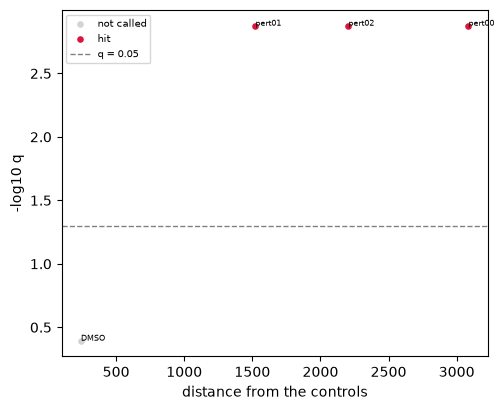

In [4]:
ax = mt.pl.hits(wells)
plt.show()

Every treated group is called, and DMSO is not, at a q-value of 0.40.
Read that as a draw rather than as a guarantee: the controls are scored against themselves on rows that took no part in fitting the centroid, so their q-value is uniform between 0 and 1 and will fall below the threshold about as often as the threshold says.
A control group surfacing in a hit list is this test working, not a fault; what would be wrong is a control row that is always safely high, which is what an in-sample null produces.

Read the warning above. `hit_calling` splits the control wells, using half to fit the
covariance and half to form the null, so 48 control wells leave 24 rows to estimate a 25×25
covariance. That is underdetermined, and the Mahalanobis distances depend more on the
regularization than on the data. The ordering here is still correct, but on a real screen
follow the warning: reduce the features first, or score a PCA representation with
`use_rep="X_pca"`. [Tutorial 0](00_overview.ipynb) does the latter, which is why it shows no
warning.

## When the median hides the effect

`method="mahalanobis"` takes the median distance of a group's rows from the control center.
That is robust, but it misses a response in part of the population: if a fifth of the cells
move a long way, the median of the whole group barely changes.

`method="ks"` compares the whole distribution of distances instead. The next cell builds this
case: a plate with no injected effect, where 20% of one perturbation's cells are shifted
strongly.

In [5]:
partial = mt.ds.synthetic_plate(n_wells=96, n_cells=40, n_features=25, n_perturbations=2, effect_size=0.0, seed=0)
mt.pp.normalize(partial, by="Metadata_Plate", reference="negcon")

rng = np.random.default_rng(0)
target = np.flatnonzero((partial.obs["Metadata_Perturbation"] == "pert00").to_numpy())
responders = rng.choice(target, size=int(0.2 * target.size), replace=False)
values = partial.X.copy()
values[responders] += 8.0
partial.X = values

for method in ("mahalanobis", "ks"):
    mt.tl.hit_calling(partial, method=method, n_permutations=1000, key_added=method)
mt.tl.edistance(partial, n_permutations=500)

summary = {}
for name in ("mahalanobis", "ks", "edistance"):
    table = partial.uns["mantispy"][name].set_index("group")
    distance = table["distance"]
    summary[name] = {
        "pert00 (20% respond)": round(float(distance["pert00"]), 3),
        "pert01 (nothing)": round(float(distance["pert01"]), 3),
        "pert00 / pert01": round(float(distance["pert00"]) / max(abs(float(distance["pert01"])), 1e-9), 2),
        "pert01 called?": bool(table.loc["pert01", "is_hit"]),
    }
summary

{'mahalanobis': {'pert00 (20% respond)': 5.259,
  'pert01 (nothing)': 5.064,
  'pert00 / pert01': 1.04,
  'pert01 called?': False},
 'ks': {'pert00 (20% respond)': 0.205,
  'pert01 (nothing)': 0.037,
  'pert00 / pert01': 5.6,
  'pert01 called?': False},
 'edistance': {'pert00 (20% respond)': 2.668,
  'pert01 (nothing)': 0.004,
  'pert00 / pert01': 657.02,
  'pert01 called?': True}}

The median Mahalanobis distance separates the responder from the unchanged group by four
percent. The KS statistic separates them more than fivefold, and the energy distance, which
compares the whole distributions, by orders of magnitude. This is the reason to keep single
cells: after aggregation, the 20% is averaged into the 80%.

The q-values need care here, and the three methods differ. Mahalanobis and KS both leave
`pert01` uncalled, which is correct because nothing was done to it. For Mahalanobis this is
not evidence of good calibration: `pert00` and `pert01` sit at a distance ratio of 1.04, so it
barely separated the two groups in either direction, and the uncalled `pert01` reflects low
sensitivity more than a correct rejection. `edistance` calls `pert01`, at a distance of 0.004
against 2.67 for `pert00`: more than six hundred times smaller, and still significant.

The energy distance works as designed here. With a thousand cells per group, its permutation
null is tight enough that almost any difference is significant, and at cell resolution almost
any two groups differ. Rank by the statistic and use the q-value to discard, not to order.
Check a method's calibration on your own screen with `mt.metrics.diagnose_testing` instead of
assuming it because the method reports a q-value.

## Which features moved

`tl.effect_size` gives Cohen's d, or a robust z with `method="robust_z"`, for every feature
and every group, with a Mann-Whitney p-value and a Benjamini-Hochberg q-value. The simulation
injected its effect into five features per perturbation, so the check is whether those five
come out on top.

In [6]:
mt.tl.effect_size(wells)
table = wells.uns["mantispy"]["effect"]
truth = wells.uns["mantispy"]["truth"]["affected_features"]

ranking = {}
for group, injected in truth.items():
    if not injected:
        continue
    ordered = list(
        table[table["group"] == group].set_index("feature")["effect"].abs().sort_values(ascending=False).index
    )
    ranking[group] = sorted(ordered.index(name) + 1 for name in injected)
{"features per group": wells.n_vars, "ranks of the injected features": ranking}

{'features per group': 25,
 'ranks of the injected features': {'pert00': [1, 2, 3, 4, 5],
  'pert01': [1, 2, 3, 4, 5],
  'pert02': [1, 2, 3, 4, 5]}}

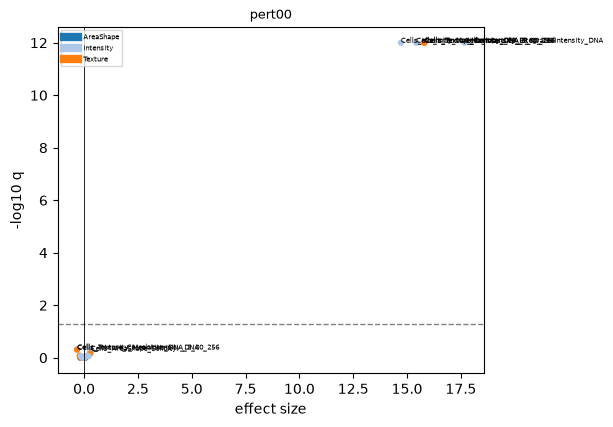

In [7]:
ax = mt.pl.feature_volcano(wells, group="pert00")
plt.show()

The five injected features take the top five places out of twenty-five in every group. The
volcano plot colors each point by what the feature measures. That annotation comes from
parsing the CellProfiler names (tutorial 1), so nothing had to be supplied here.

## A change in shape

An effect size compares locations. A perturbation that widens a feature's distribution
without moving its center has an effect size of zero, but it is still a biological change:
some cells reacted and others did not.

`tl.wasserstein_features` compares the distributions themselves.

In [8]:
spread = wells.copy()
values = spread.X.copy()
selected = (spread.obs["Metadata_Perturbation"] == "pert01").to_numpy()
values[selected, 0] = rng.standard_normal(int(selected.sum())) * 5.0
spread.X = values

mt.tl.effect_size(spread)
mt.tl.wasserstein_features(spread)

position = spread.uns["mantispy"]["effect_groups"].index("pert01")
{
    "feature": str(spread.var_names[0]),
    "cohen's d": round(float(spread.varm["effect"][0, position]), 3),
    "wasserstein": round(float(spread.varm["wasserstein"][0, position]), 3),
}

{'feature': 'Cells_AreaShape_Area', "cohen's d": -0.296, 'wasserstein': 4.008}

Cohen's d is 0.3, a small effect by any convention, and it is that large only because
pert01's median already differed slightly from the control median. The Wasserstein distance
is thirteen times larger. Ranked by effect size, this feature does not stand out; ranked by
distributional distance, it is first.

## One profile per perturbation

`tl.consensus` collapses replicates into one signature per perturbation. The default,
`modz`, weights each replicate by how well it agrees with the others, so a single bad well
is down-weighted instead of averaged in.

modz is a weighted mean. It beats the plain mean by a wide margin but does not beat the
median. On BBBC021, not-same-compound MOA retrieval is 0.777 with `method="median"` and 0.660
with modz. Compare both on your own data.

In [9]:
signatures = mt.tl.consensus(wells, method="modz")
weights = signatures.uns["mantispy"]["consensus_weights"]
{
    "signatures": signatures.shape,
    "resolution": signatures.uns["mantispy"]["resolution"],
    "weights sum to one per group": bool(np.allclose(weights.groupby("group")["weight"].sum(), 1.0, atol=1e-3)),
}

{'signatures': (4, 25),
 'resolution': 'perturbation',
 'weights sum to one per group': True}

## Dose response

With a concentration series, the question becomes whether the effect grows with dose. An
active compound gives a monotonic trend and a sigmoid curve; a well-position artifact does
not.

`tl.dose_response` reports a Spearman trend for every compound, which assumes nothing about
the curve's shape, and fits a four-parameter logistic for an EC50 wherever there are at least
`min_doses` distinct doses. The minimum exists because four parameters fitted to three points
give a number without support.

In [10]:
from mantispy.tl._dose import four_parameter_logistic

dosed = wells.copy()
n = dosed.n_obs
dose = np.tile([0.01, 0.1, 1.0, 10.0, 100.0], n)[:n]
compound = rng.permutation(np.where(np.arange(n) % 2 == 0, "active", "flat"))
dosed.obs["Metadata_Compound"] = compound
dosed.obs["Metadata_Concentration"] = dose

true_ec50 = 1.0
response = np.where(
    compound == "active",
    four_parameter_logistic(np.log10(dose), 0.0, 10.0, np.log10(true_ec50), 1.5),
    0.0,
)
dosed.obs["hits_distance"] = response + rng.normal(0, 0.2, n)

mt.tl.dose_response(dosed)
dosed.uns["mantispy"]["dose_response"].round(3)

,compound,n_doses,spearman,pvalue,ec50,hill_slope,bottom,top,r_squared,fit_ok,qvalue
0,active,5,0.939,0.000,0.992,1.537,0.023,9.941,0.998,True,0.000
1,flat,5,-0.130,0.207,113.598,6.754,0.020,-0.265,0.043,False,0.207


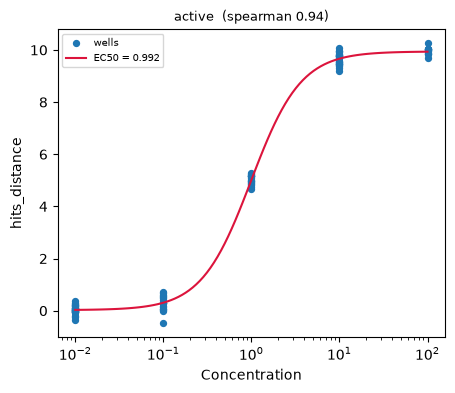

In [11]:
ax = mt.pl.dose_response(dosed, compound="active")
plt.show()

The fitted EC50 matches the concentration the curve was built with, and the compound with no
dose dependence has no trend.

The flat compound's row is also worth reading. The optimizer converged on it and reports an
EC50 of 113.6 and a Hill slope of 6.8, which look like a result on their own. Four parameters
fitted to five points converge on almost anything: on pure noise at six doses the optimizer
succeeds 59 times in 60.

`r_squared` and `fit_ok` catch this. The curve explains 4% of the flat compound's variance
against 99.8% for the active one, and its EC50 lies outside the tested doses, so it is an
extrapolation. `fit_ok` requires both a good fit and an EC50 inside the tested range, so the
flat row fails. Check the Spearman trend and its q-value first in any case: a monotonic trend
assumes nothing about shape and works with three points, where an EC50 fit does not.

## What is on the object now

Every result is stored on the object, so `mt.io.write` saves all of it and a later session
can continue from here.

| what | where |
|---|---|
| hit table | `uns["mantispy"]["hits"]` |
| per-row distance and q | `obs["hits_distance"]`, `obs["hits_qvalue"]` |
| effect sizes | `varm["effect"]` and `uns["mantispy"]["effect"]` |
| Wasserstein distances | `varm["wasserstein"]` and `uns["mantispy"]["wasserstein"]` |
| e-distances | `uns["mantispy"]["edistance"]` |
| dose response | `uns["mantispy"]["dose_response"]` |
| replicate weights | `uns["mantispy"]["consensus_weights"]` on the consensus object |

Next: [mechanism of action](06_mechanism_of_action.ipynb), on real data.